# Tarea 3 - Ciencia de Datos
#### Gustavo Hernández Angeles

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# Aprendizaje No Supervisado
from sklearn.cluster import (
    AgglomerativeClustering,
    DBSCAN,
    KMeans,
    MeanShift,
    SpectralClustering
)
from sklearn.decomposition import (
    KernelPCA
)
# Métricas
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score
)
import utils.utils as u
import cv2
import os
from typing import Literal

from sklearn.feature_extraction.text import CountVectorizer

import nltk
from nltk.corpus import stopwords
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from transformers import BertTokenizer, BertModel
import torch
import pickle

## Leer el conjunto de datos

In [8]:
def extraeImagenTexto(path_images, path_labels, size, seed):    
    # Obtenemos imagenes aleatoriamente.
    np.random.seed(seed)    
    image_names = [file.name for file in path_images.glob("*.jpg")]
    image_names = np.random.choice(image_names,size=size,replace=False)
    
    # Leemos el df con etiquetas
    df = pd.read_csv(path_labels, sep="|")
    df.rename(columns=lambda x: x.strip(), inplace=True)

    # Obtenemos los textos de las imagenes.
    image_texts = []
    df_textos = df.groupby("image_name")["comment"].sum()
    for image_name in image_names:
        image_texts.append(df_textos.loc[image_name])
    
    return image_names, image_texts

In [9]:
dir_images = Path("../data/flickr30k_images/")
file_labels = Path("../data/results.csv")

image_names, image_texts = extraeImagenTexto(dir_images, file_labels, size=1000,
                                             seed=1825)

n_images = len(image_names)

print(f"Imagenes leidas: {n_images}")
print(image_names[:2])
print(image_texts[:2])

Imagenes leidas: 1000
['6064872574.jpg' '1538738682.jpg']
[' An old woman seated and wearing glasses making necklaces out of beads under the light of a fluorescent bulb . A woman wearing eyeglasses , sitting in front of the table while making jewelries . A brown-haired woman wearing spectacles crafts jewelery by hand using a desk lamp . A woman is sitting by a desk crafting necklaces out of assorted beads by hand . A middle-aged woman assembles jewelry .', ' A child is sleeping in the front passenger seat of a car with the window slightly open . A child sleeps viewed through a window of a car which is cracked slightly . A young child is sleeping inside a vehicle that is parked outside . A child asleep in a car with the window open A child is sleeping in a car .']


## Representación de Imagenes

In [10]:
def image2Hist(dir_images, image_names, type : Literal["gris","color","combinado"]):
    dim_por_representacion = {
        "gris" : 256,
        "color" : 768,
        "combinado" : 256+768
    }

    if type not in ["gris", "color", "combinado"]:
        raise ValueError('Type debe ser uno de ("gris","color","combinado").')
    
    X = np.zeros((n_images, dim_por_representacion[type]))
    
    
    for i in range(X.shape[0]):
        image_path = os.path.join(dir_images, image_names[i])
        img = cv2.imread(image_path)
        
        if type == "combinado":
            X[i] = np.concatenate([u.obtener_histograma_gris(img),u.obtener_histograma_color(img)])
        elif type == "gris":
            X[i] = u.obtener_histograma_gris(img)
        else:
            X[i] = u.obtener_histograma_color(img)
    
    return X

def image2ORB(dir_images, image_names):
    """
    Calcula los descriptores ORB promedio para una lista de imágenes.

    Parámetros:
    - dir_images (str): Directorio donde se encuentran las imágenes.
    - image_names (list): Lista con los nombres de las imágenes.

    Retorna:
    - Matriz (n_imágenes, 32) con los descriptores ORB promediados.
    """
    n_images = len(image_names)
    dim_descriptor = 32  # Tamaño del descriptor ORB promedio
    X = np.zeros((n_images, dim_descriptor))

    orb = cv2.ORB_create(nfeatures=500)  # ORB detector

    for i, image_name in enumerate(image_names):
        image_path = os.path.join(dir_images, image_name)
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # ORB funciona mejor en escala de grises
        
        if img is None:
            continue  # Si no se puede leer la imagen, se deja el vector en ceros

        keypoints, descriptors = orb.detectAndCompute(img, None)

        if descriptors is not None:
            X[i] = np.mean(descriptors, axis=0)

    return X

In [11]:
imgPorIntensidad = image2Hist(dir_images, image_names, type="gris")
imgPorIntensidad.shape

(1000, 256)

In [12]:
imgPorColor = image2Hist(dir_images, image_names, type="color")
imgPorColor.shape

(1000, 768)

In [13]:
imgCombinado = image2Hist(dir_images, image_names, type="combinado")
imgCombinado.shape

(1000, 1024)

In [14]:
imgPorORB = image2ORB(dir_images, image_names)
imgPorORB.shape

(1000, 32)

' Several young children in Halloween costumes watching an outdoor event . children dressed in Halloween costumes are enjoying a performance . trick or treaters are sitting on the side of a porch . Several kinds and adults sit on a porch at night Four little kids in cute outfits sitting down .'

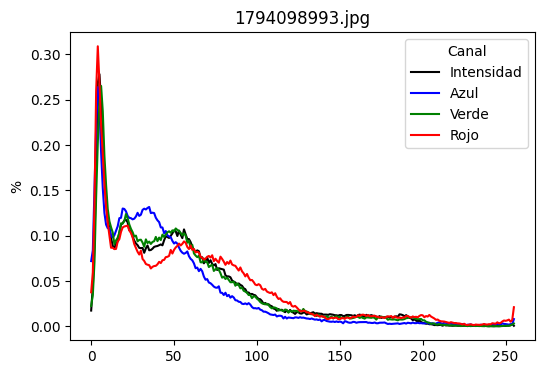

In [15]:
i = 18
plt.figure(figsize=(6,4))
g1 = u.plot_histograms(imgCombinado[i])
plt.title(f"{image_names[i]}")
plt.xlabel("")
plt.ylabel("%")
sns.move_legend(g1, loc="best")
plt.savefig("histograma.pdf", bbox_inches="tight")
image_texts[i]

In [16]:
# Todas las representaciones en imagenes concatenadas
X_image = np.concatenate([imgPorIntensidad, imgPorColor, imgPorORB], axis=1)

## Representación de Textos

BoW

In [17]:
vectorizer = CountVectorizer(
    token_pattern=r"[a-z]+",
    stop_words=stopwords.words("english")
    )

bow = vectorizer.fit_transform(image_texts).toarray()

Doc2Vec

In [18]:
tagged_docs = [TaggedDocument(doc.split(), [i]) for i, doc in enumerate(image_texts)]

doc2vec_model = Doc2Vec(tagged_docs, vector_size=20, window=2,
                        min_count=1, workers=6, epochs=50)

doc2vec_vectors = np.array([doc2vec_model.dv[i] for i in range(len(image_texts))])

BERT

In [19]:
# Verificar si hay GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
device.__str__()=="cuda"

Usando dispositivo: cuda


True

In [20]:

model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)

if device.__str__() == "cuda" :
    model = BertModel.from_pretrained(model_name).to(device)  # Mover modelo a GPU
else:
    model = BertModel.from_pretrained(model_name)
def obtener_embeddings_bert(texto):
    """
    Toma un texto de entrada y devuelve su embedding generado por BERT.

    Parámetros:
    - texto (str): Texto de entrada.

    Retorna:
    - Embedding de la oración (vector promedio de los tokens).
    """
    # Tokenizar el texto y convertirlo en tensores y moverlos a GPU
    tokens = tokenizer(texto, return_tensors="pt", padding=True, truncation=True, max_length=512)
    if device.__str__() == "cuda":
        tokens = {key: val.to(device) for key, val in tokens.items()}  # Mover tensores a GPU
    else:
        tokens = {key: val for key, val in tokens.items()}
    
    # Pasar los tokens por el modelo BERT
    with torch.no_grad():
        outputs = model(**tokens)

    # Extraer los embeddings de la última capa oculta
    embeddings = outputs.last_hidden_state  # (batch_size, num_tokens, hidden_dim)

    if device.__str__() == "cuda":
        # Obtener el embedding promedio de la oración (ignorar [CLS] y [SEP])
        embedding_promedio = embeddings.mean(dim=1).squeeze().cpu().numpy()  # Mover a CPU antes de convertir a numpy
    else:
        embedding_promedio = embeddings.mean(dim=1).squeeze().numpy()
    return embedding_promedio

# Suponiendo que `image_texts` es una lista de textos
embeddings_bert = np.array([obtener_embeddings_bert(texto) for texto in image_texts])


In [21]:
embeddings_bert.shape

(1000, 768)

In [22]:
# Todas las representaciones de texto combinadas
X_text = np.concatenate([bow, doc2vec_vectors, embeddings_bert], axis=1)

In [23]:
# Todas las representaciones combinadas
X_all = np.concatenate([X_image, X_text], axis=1)

## Algoritmos de Agrupamiento

In [24]:
def aplicar_clustering(X, metodo : Literal["kmeans" , "dbscan", "jerarquico", "mean-shift",
                                           "gmm", "spectral"] ="kmeans",
                       n_clusters=3, eps=5, min_samples=5):
    """
    Aplica diferentes algoritmos de clustering a una matriz de datos X.

    Parámetros:
    - X (numpy.ndarray): Matriz de datos (n_muestras, n_features).
    - metodo (str): Algoritmo de clustering a aplicar ("kmeans", "dbscan", "jerarquico", "mean-shift", "gmm", "spectral").
    - n_clusters (int): Número de clusters (para algoritmos que lo requieren).
    - eps (float): Parámetro de distancia para DBSCAN.
    - min_samples (int): Mínimo de muestras por cluster en DBSCAN.

    Retorna:
    - labels (numpy.ndarray): Etiquetas asignadas a cada muestra en X.
    - centroids (numpy.ndarray | None): Centros de los clusters si el método lo permite, de lo contrario None.
    """
    metodo = metodo.lower()
    labels = None
    centroids = None

    if metodo == "kmeans":
        model = KMeans(n_clusters=n_clusters, random_state=420)
        labels = model.fit_predict(X)
        centroids = model.cluster_centers_

    elif metodo == "dbscan":
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X)

    elif metodo == "jerarquico":
        model = AgglomerativeClustering(n_clusters=n_clusters)
        labels = model.fit_predict(X)

    elif metodo == "mean-shift":
        model = MeanShift()
        labels = model.fit_predict(X)
        centroids = model.cluster_centers_

    elif metodo == "gmm":
        model = GaussianMixture(n_components=n_clusters, random_state=42)
        labels = model.fit_predict(X)
        centroids = model.means_

    elif metodo == "spectral":
        model = SpectralClustering(n_clusters=n_clusters, random_state=42, affinity="nearest_neighbors")
        labels = model.fit_predict(X)

    else:
        raise ValueError("Método no reconocido. Usa 'kmeans', 'dbscan', 'jerarquico', 'mean-shift', 'gmm' o 'spectral'.")

    return labels, centroids

In [25]:
def aplicar_pca(X, n_componentes=3, kernel="linear", **kwargs):
    """
    Aplica PCA o KernelPCA a una matriz de datos X.

    Parámetros:
    - X (numpy.ndarray): Matriz de datos (n_muestras, n_features).
    - n_componentes (int): Número de componentes principales a retener.
    - kernel (str): Kernel a usar en KernelPCA ("linear", "poly", "rbf", "sigmoid", "cosine").
    - **kwargs: Parámetros adicionales para KernelPCA (ej. gamma, degree, coef0).

    Retorna:
    - X_transformado (numpy.ndarray): Matriz reducida con las componentes principales.
    - explained_variance (numpy.ndarray | None): Varianza explicada si el kernel es lineal, de lo contrario None.
    """
    kpca = KernelPCA(n_components=n_componentes, kernel=kernel, **kwargs)
    X_transformado = kpca.fit_transform(X)
    
    explained_variance = None
    if kernel == "linear":
        explained_variance = np.var(X_transformado, axis=0) / np.sum(np.var(X_transformado, axis=0))

    return X_transformado, explained_variance

## Evaluación de Resultados

In [ ]:
def plot_clusters_3d(X_transformed, labels, show_labels=False, title="Clusters in 3D PCA Space"):
    """
    Visualiza los clusters en un espacio tridimensional con colores diferenciados.

    Parámetros:
    - X_transformed (numpy.ndarray): Datos transformados a 3D (n_samples, 3).
    - labels (numpy.ndarray): Etiquetas de los clusters.
    - show_labels (bool): Si True, muestra los índices de cada punto.
    - title (str): Título del gráfico.
    """
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': '3d'})

    # Scatter plot con colores por cluster
    scatter = ax.scatter(
        X_transformed[:, 0], X_transformed[:, 1], X_transformed[:, 2], 
        c=labels, cmap='viridis', s=20, edgecolors='k', alpha=0.8
    )

    # Opcional: Agregar etiquetas a los puntos
    if show_labels:
        for i in range(X_transformed.shape[0]):
            ax.text(X_transformed[i, 0], X_transformed[i, 1], X_transformed[i, 2], 
                    f"{i}", fontsize=7, color='black', alpha=0.7)

    # Configuración de ejes y título
    ax.set_xlabel("PC1", fontsize=12)
    ax.set_ylabel("PC2", fontsize=12)
    ax.set_zlabel("PC3", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')

    # Ajustar ángulo de la vista para mejor perspectiva
    ax.view_init(elev=20, azim=135)

    return fig

def experimentacion(X,representacion, metodo, n_clusters, kernel, show_labels=False, save = False):
    X_transformed, explained_variance = aplicar_pca(X, n_componentes=3, kernel=kernel)    
    labels, centroids = aplicar_clustering(X_transformed, metodo=metodo, n_clusters=n_clusters)
    plot_clusters_3d(X_transformed, labels, title=f"Clusters en 3D ({metodo}, {kernel})", show_labels=show_labels)
    if save:
        plt.savefig(f"./figures/{metodo}/{metodo}-{kernel}-{representacion}.pdf", bbox_inches="tight")
    if len(set(labels)) > 1:
        return silhouette_score(X, labels)
    return -1

Experimentación

Experimentando con algoritmo kmeans y kernel linear en representación de Histograma de intensidad.
Experimentando con algoritmo kmeans y kernel linear en representación de Histograma de color.
Experimentando con algoritmo kmeans y kernel linear en representación de ORB.
Experimentando con algoritmo kmeans y kernel rbf en representación de Histograma de intensidad.
Experimentando con algoritmo kmeans y kernel rbf en representación de Histograma de color.
Experimentando con algoritmo kmeans y kernel rbf en representación de ORB.
Experimentando con algoritmo dbscan y kernel linear en representación de Histograma de intensidad.
Experimentando con algoritmo dbscan y kernel linear en representación de Histograma de color.
Experimentando con algoritmo dbscan y kernel linear en representación de ORB.
Experimentando con algoritmo dbscan y kernel rbf en representación de Histograma de intensidad.
Experimentando con algoritmo dbscan y kernel rbf en representación de Histograma de color.
Experimen

C:\Users\Gus\AppData\Local\Temp\ipykernel_16736\3505254356.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': '3d'})


Experimentando con algoritmo mean-shift y kernel rbf en representación de Histograma de intensidad.
Experimentando con algoritmo mean-shift y kernel rbf en representación de Histograma de color.
Experimentando con algoritmo mean-shift y kernel rbf en representación de ORB.
Experimentando con algoritmo gmm y kernel linear en representación de Histograma de intensidad.
Experimentando con algoritmo gmm y kernel linear en representación de Histograma de color.
Experimentando con algoritmo gmm y kernel linear en representación de ORB.
Experimentando con algoritmo gmm y kernel rbf en representación de Histograma de intensidad.
Experimentando con algoritmo gmm y kernel rbf en representación de Histograma de color.
Experimentando con algoritmo gmm y kernel rbf en representación de ORB.
Experimentando con algoritmo spectral y kernel linear en representación de Histograma de intensidad.
Experimentando con algoritmo spectral y kernel linear en representación de Histograma de color.
Experimentando

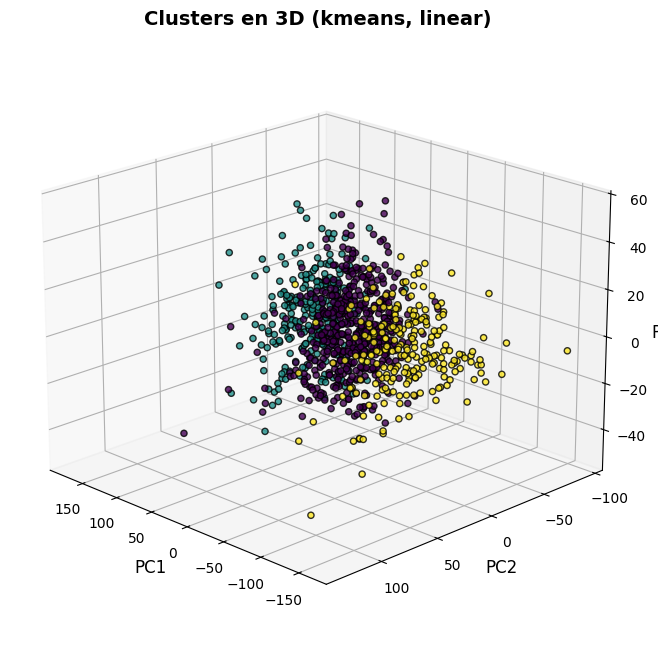

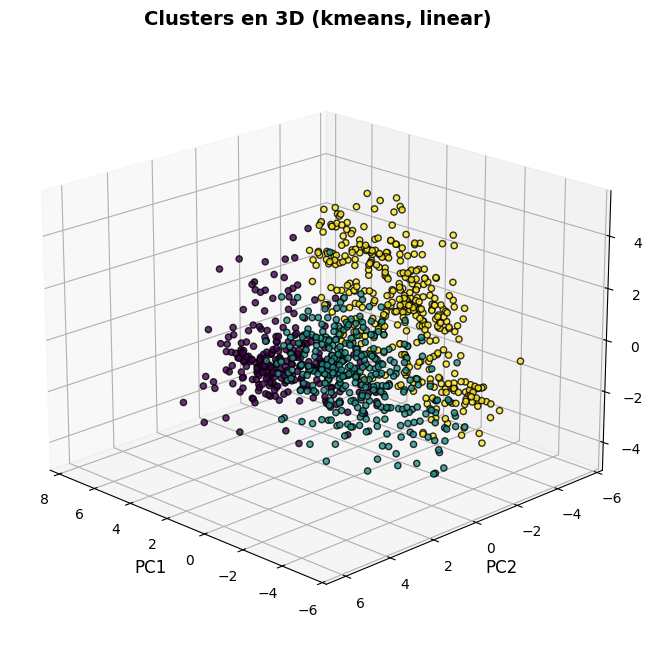

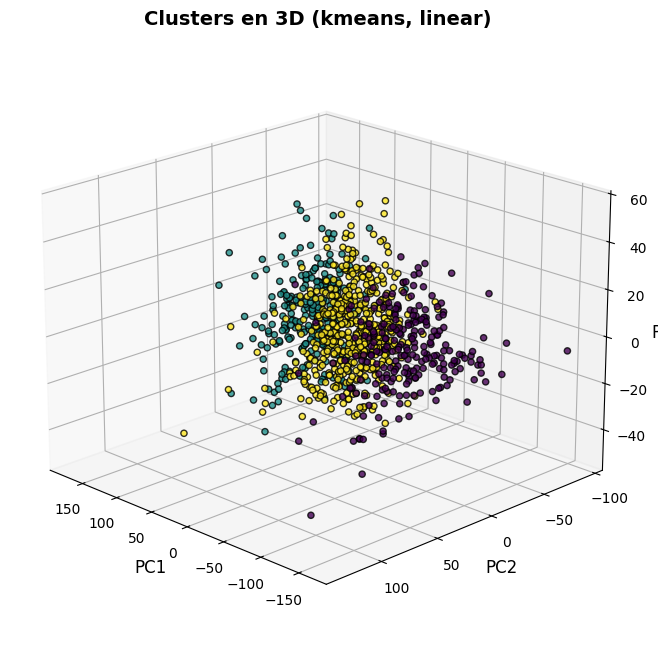

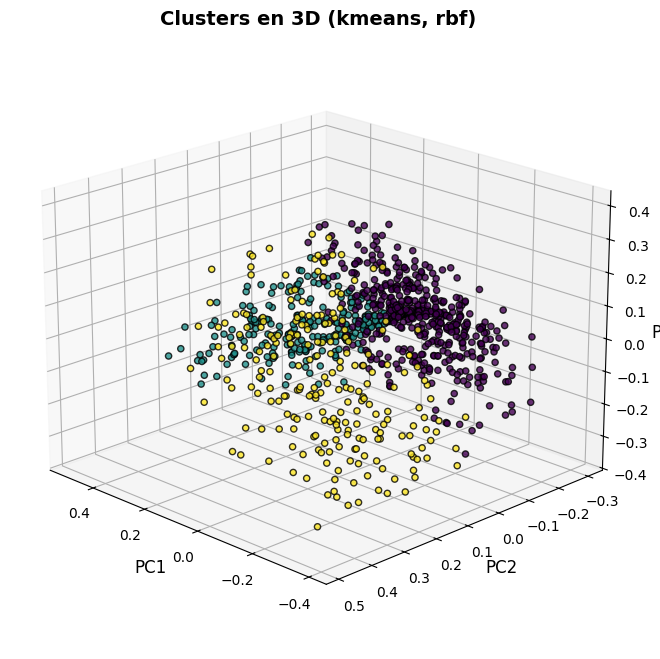

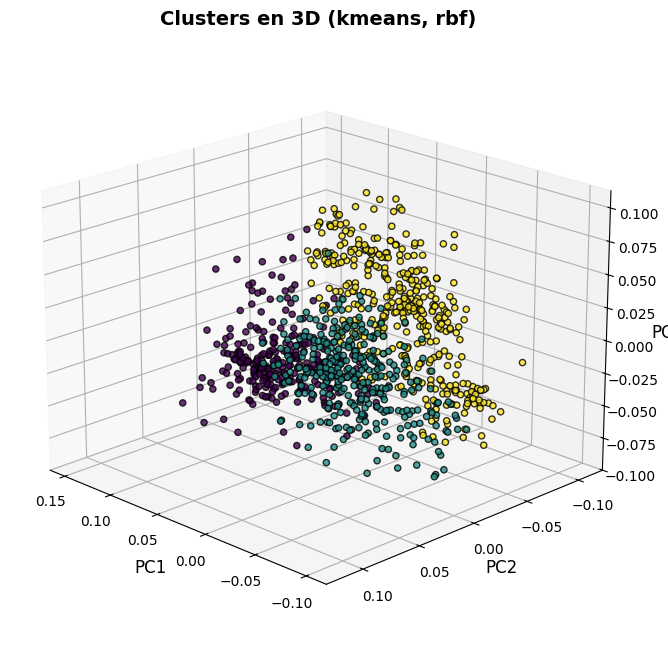

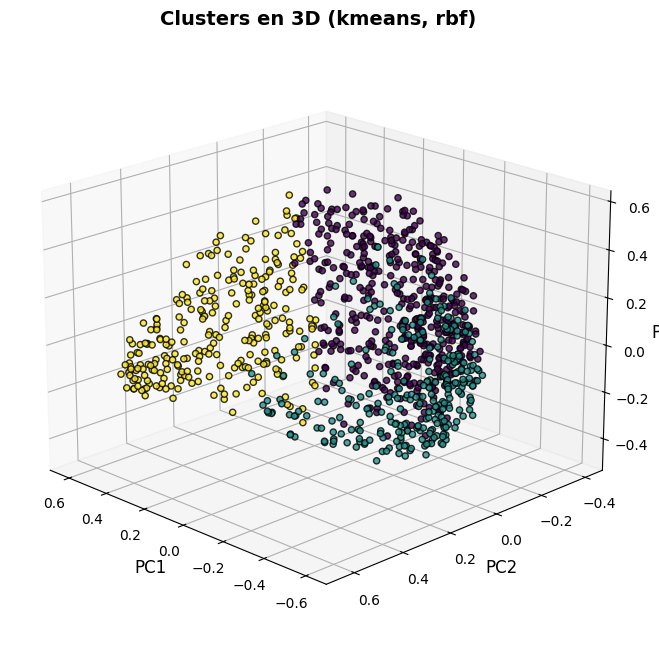

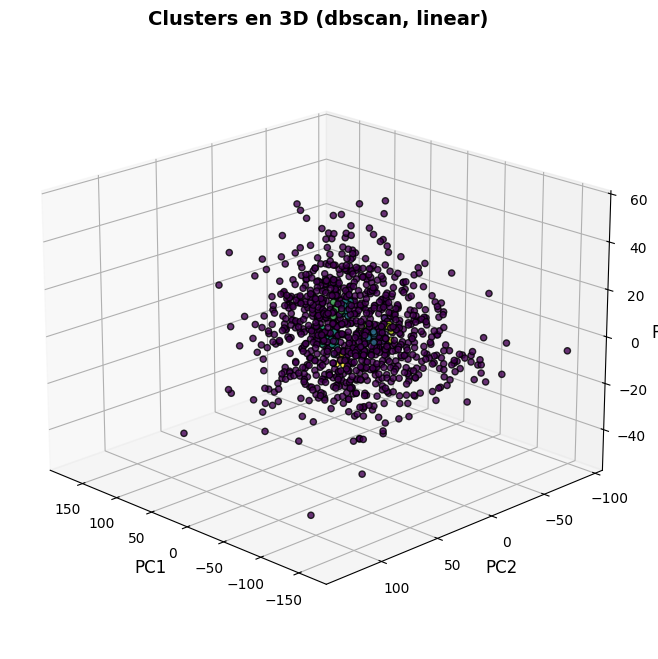

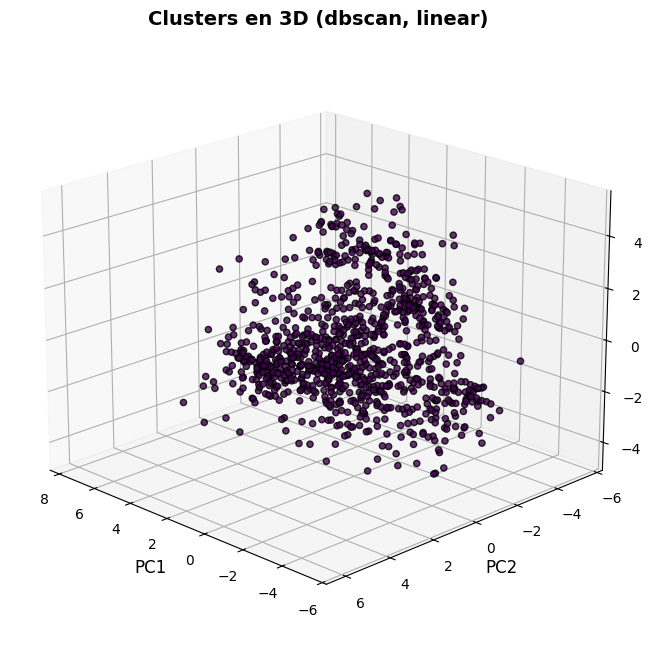

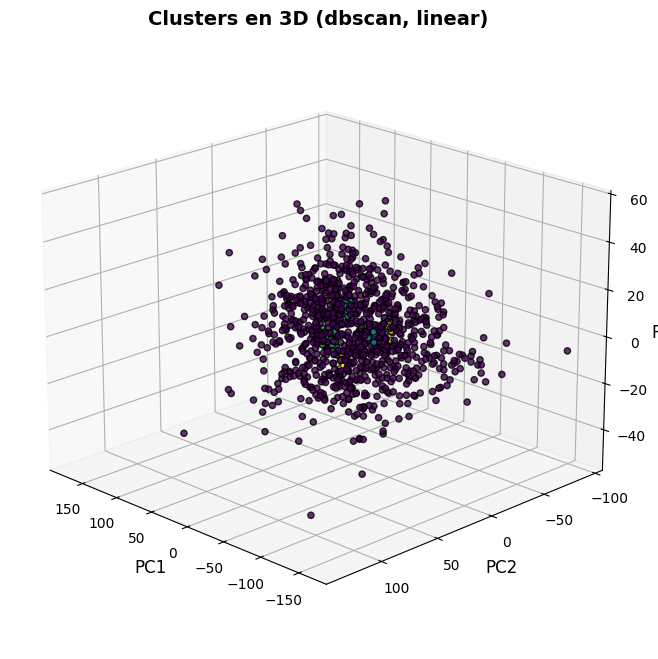

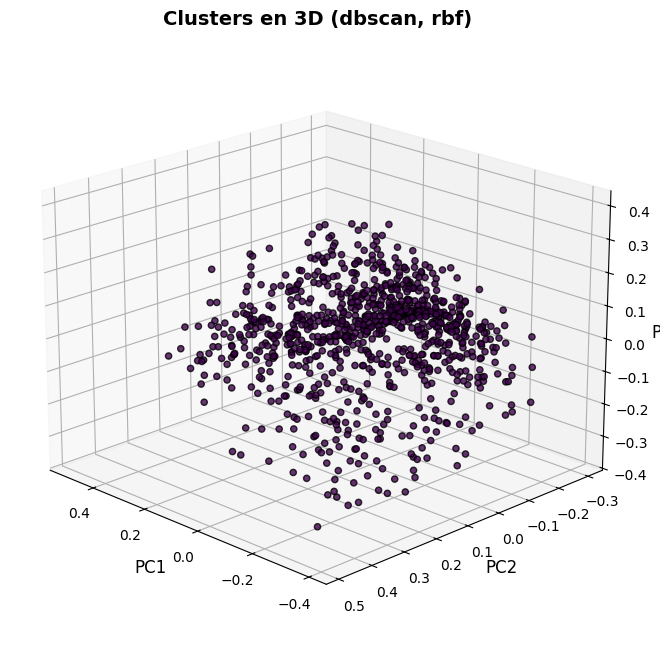

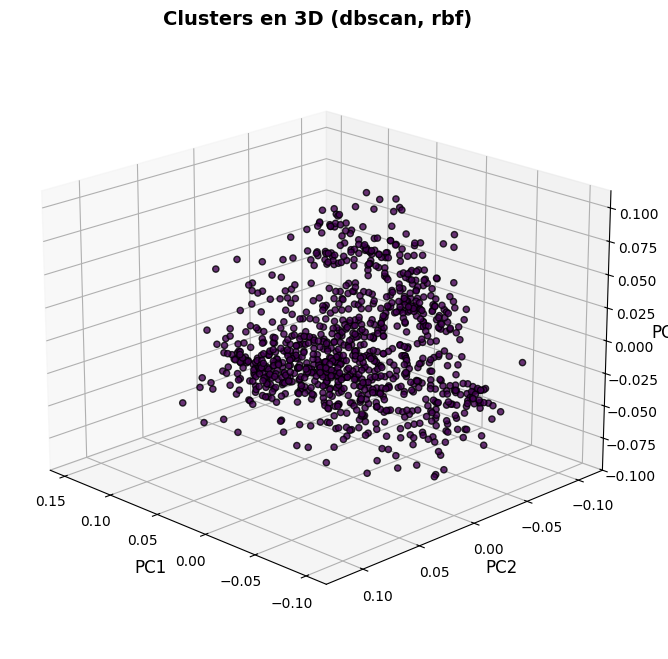

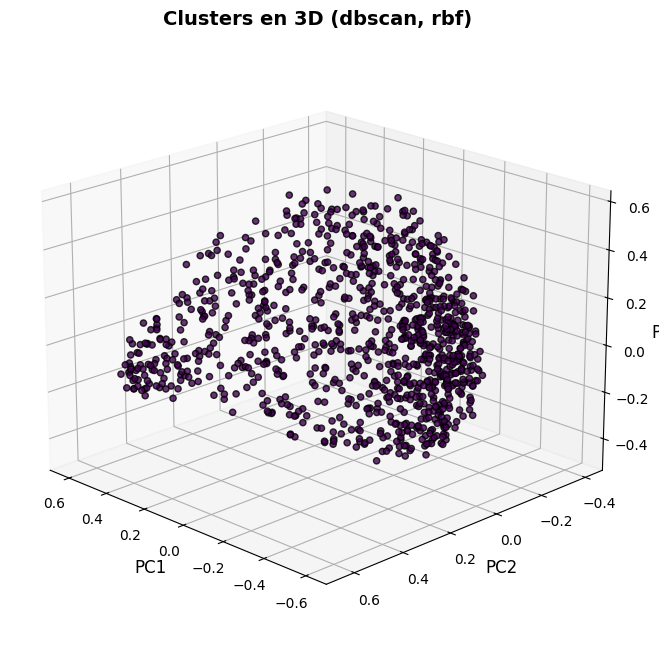

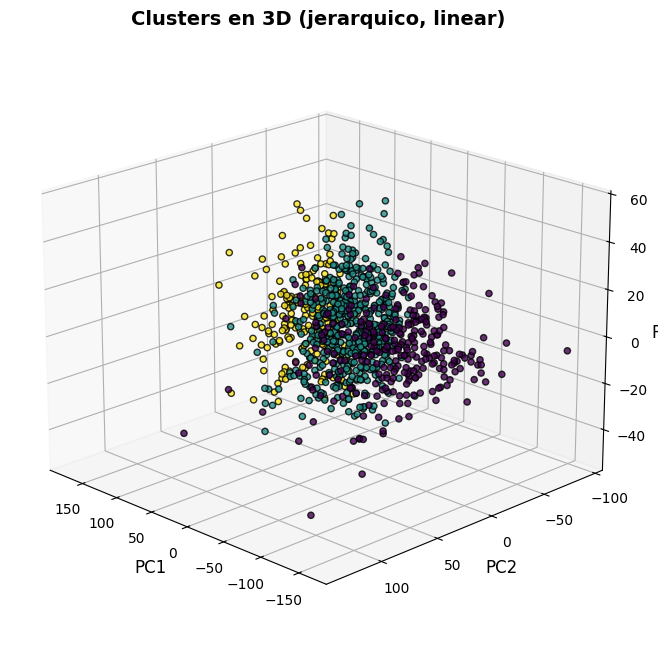

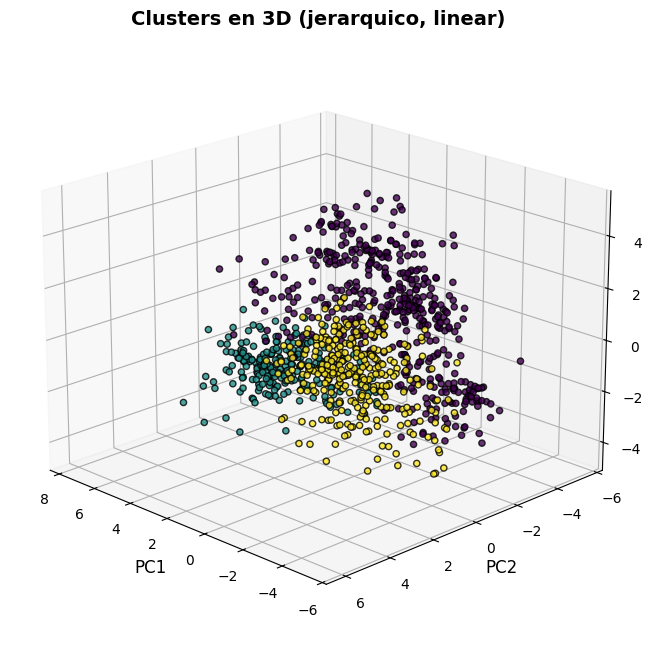

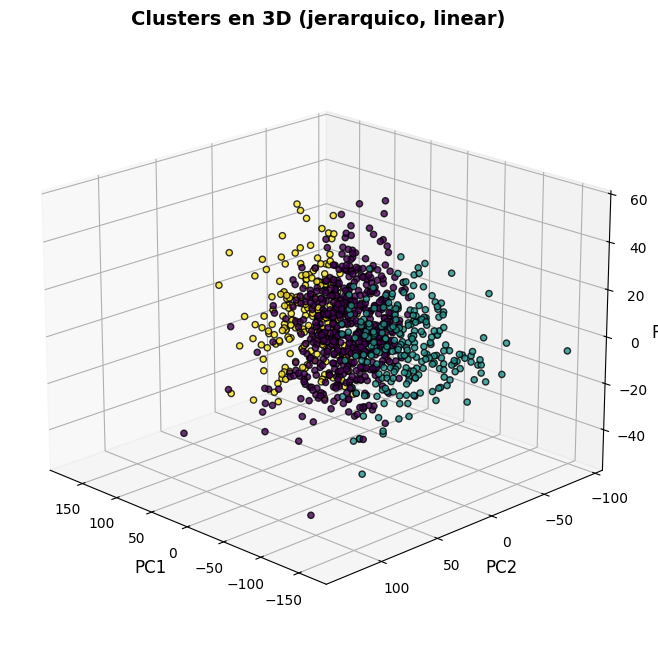

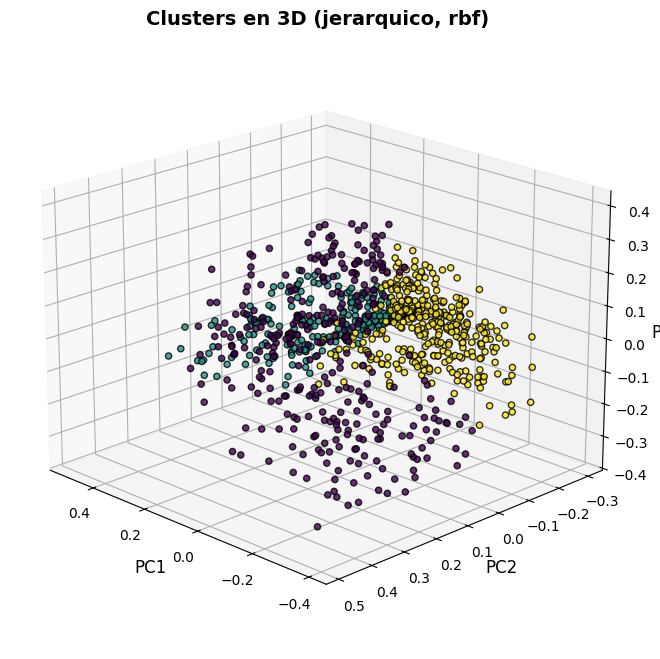

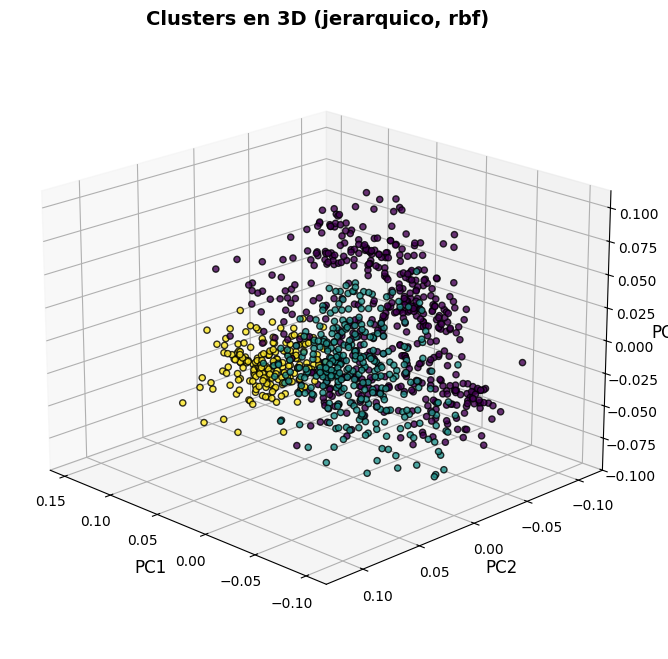

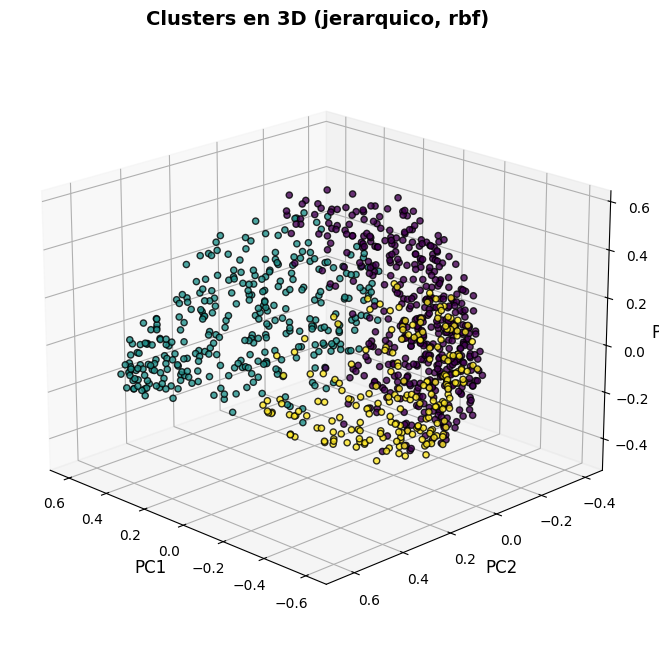

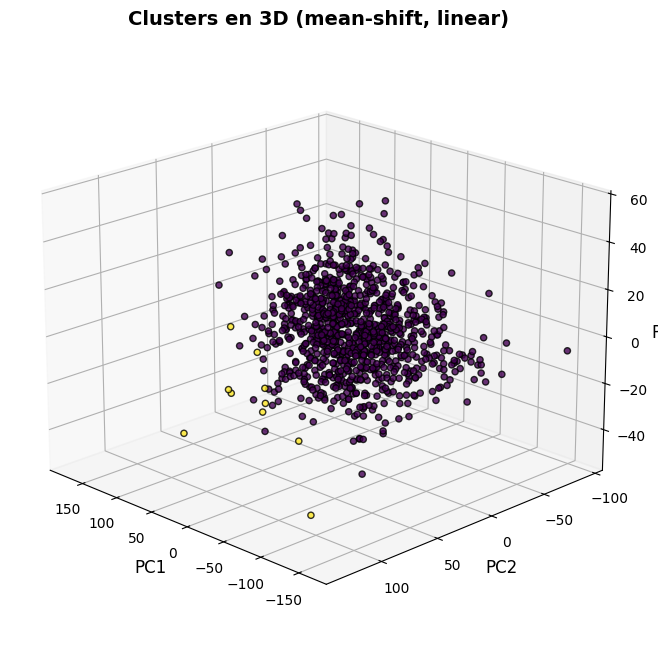

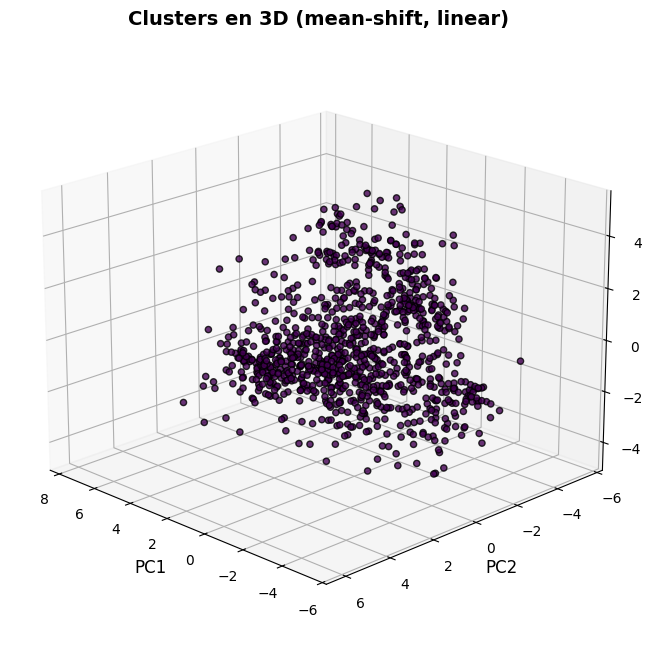

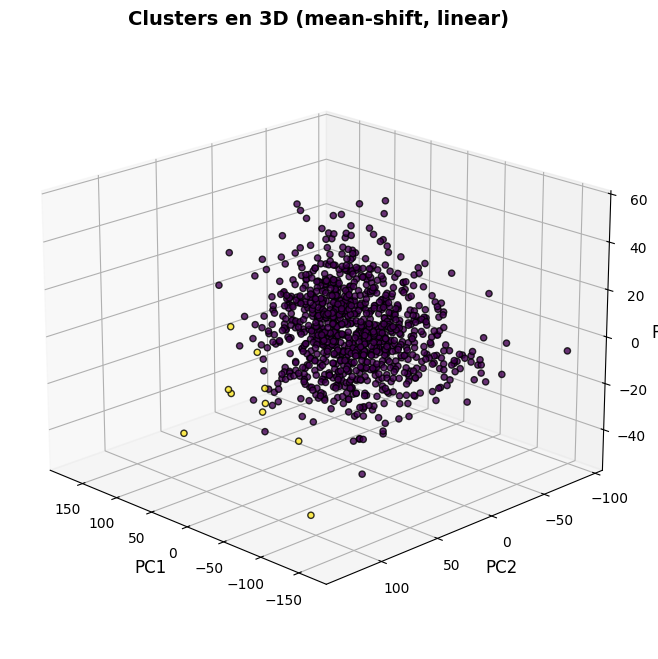

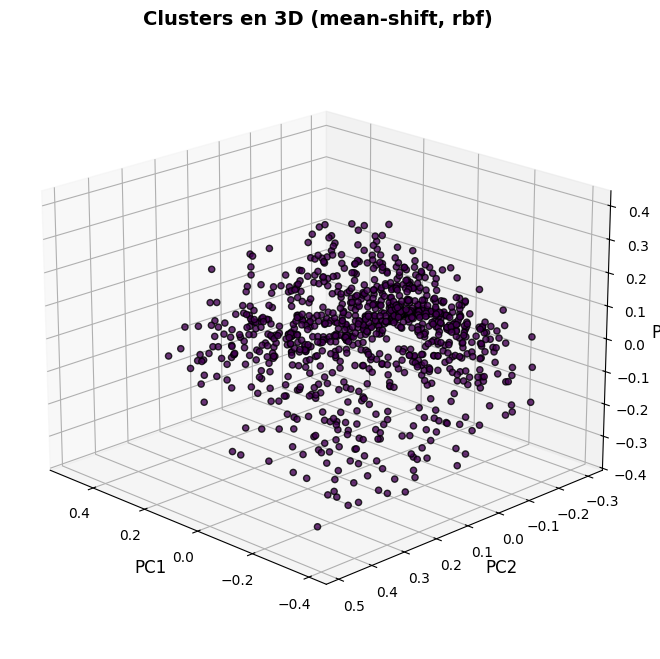

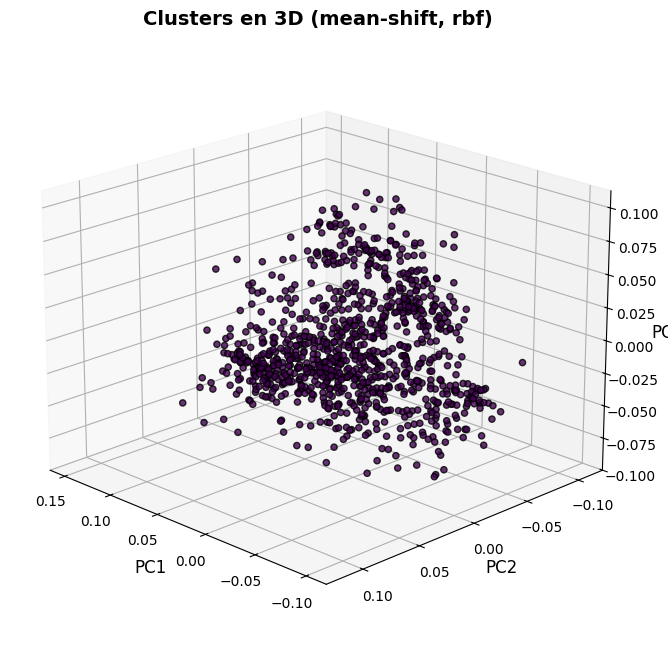

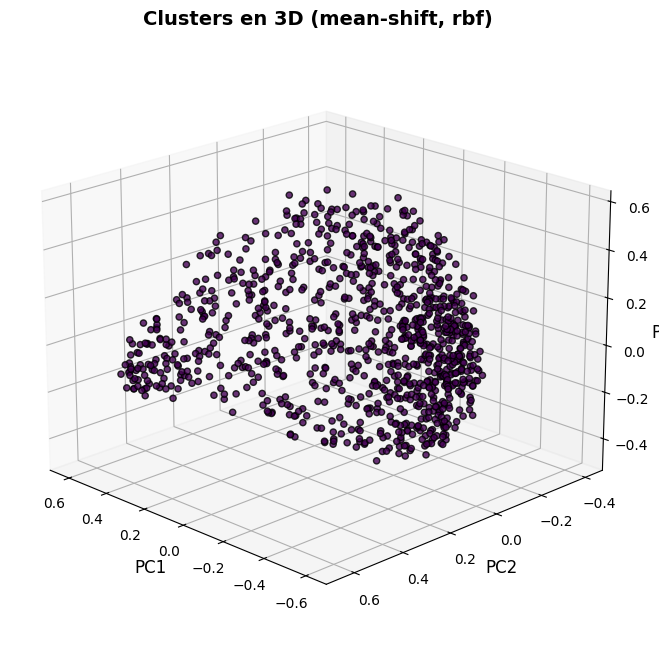

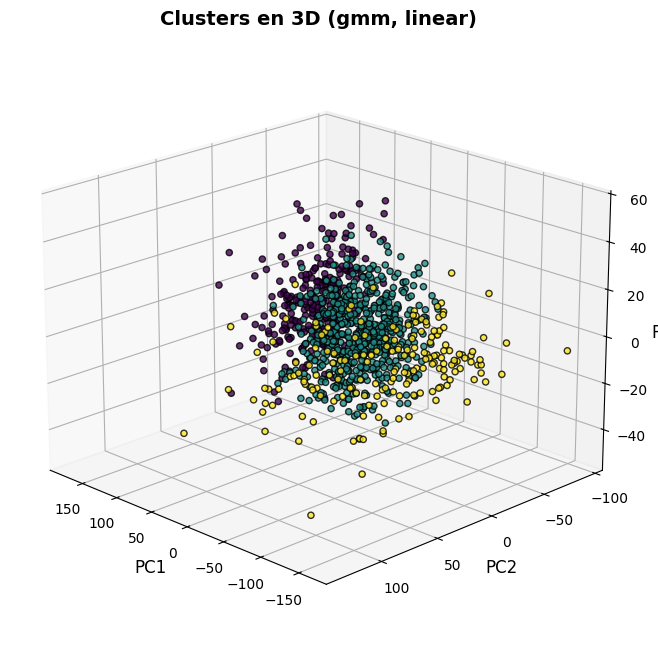

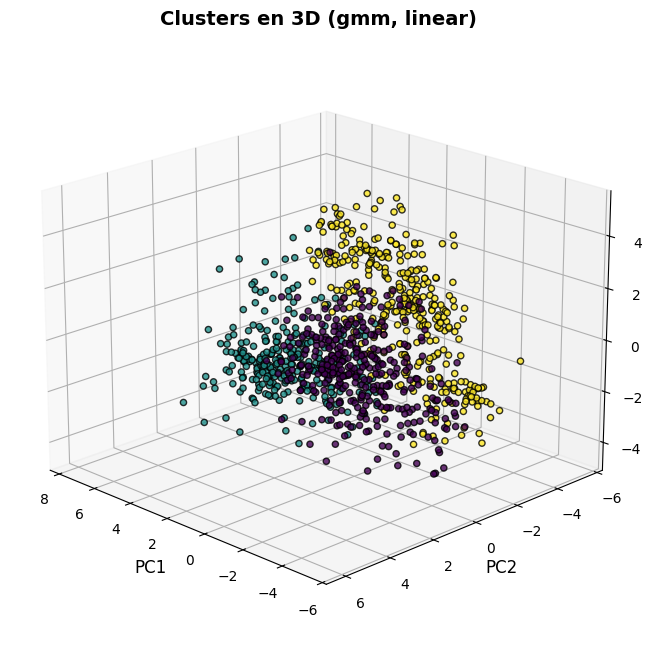

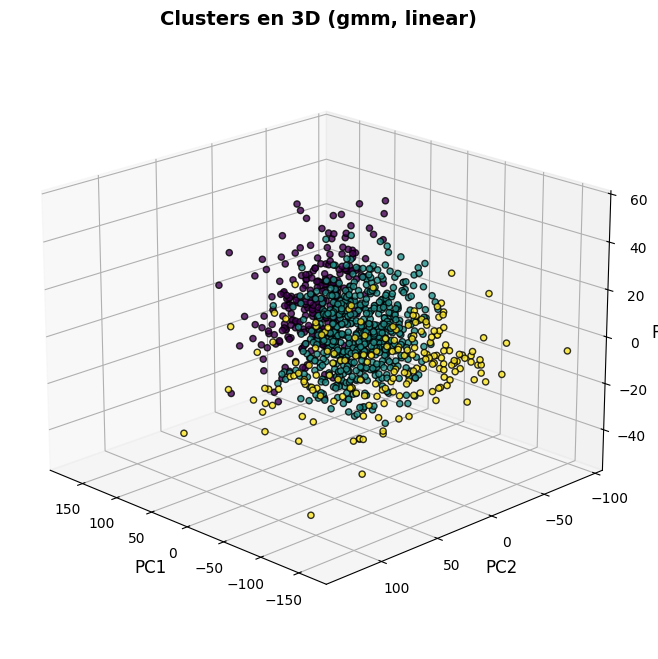

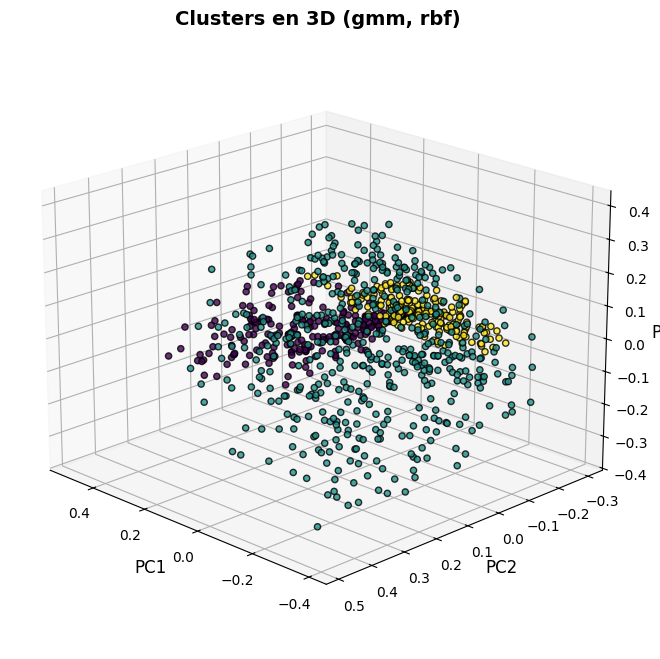

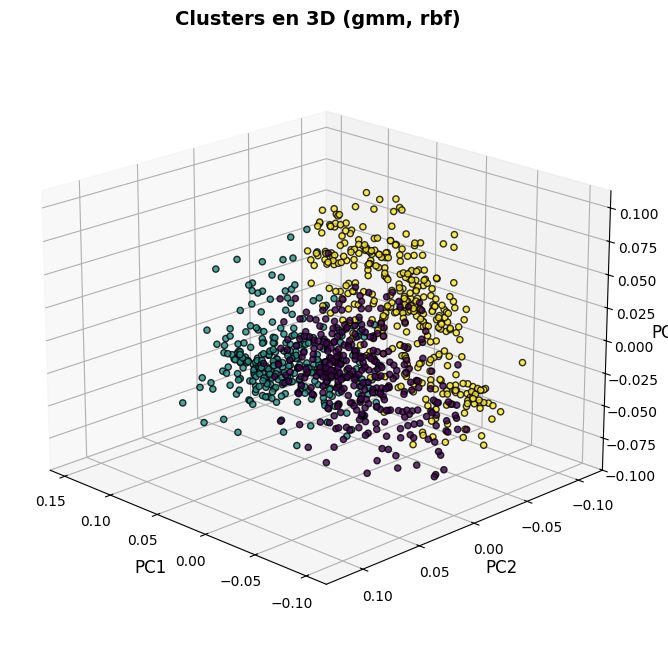

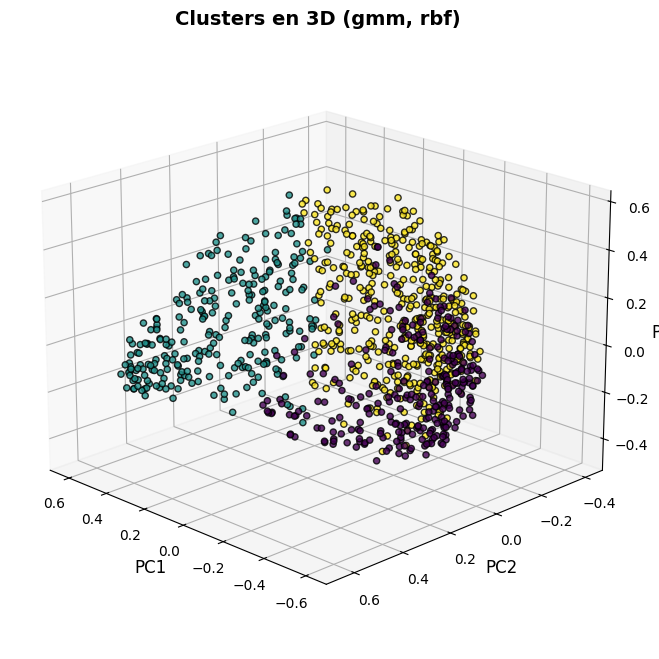

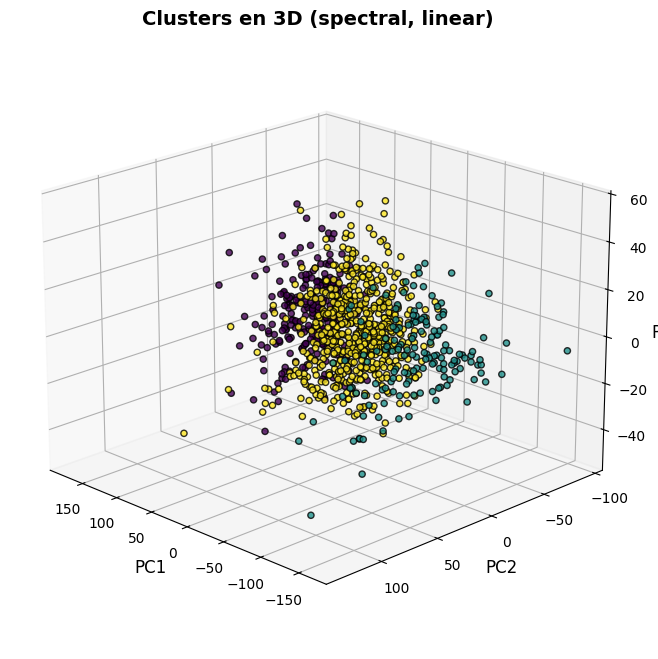

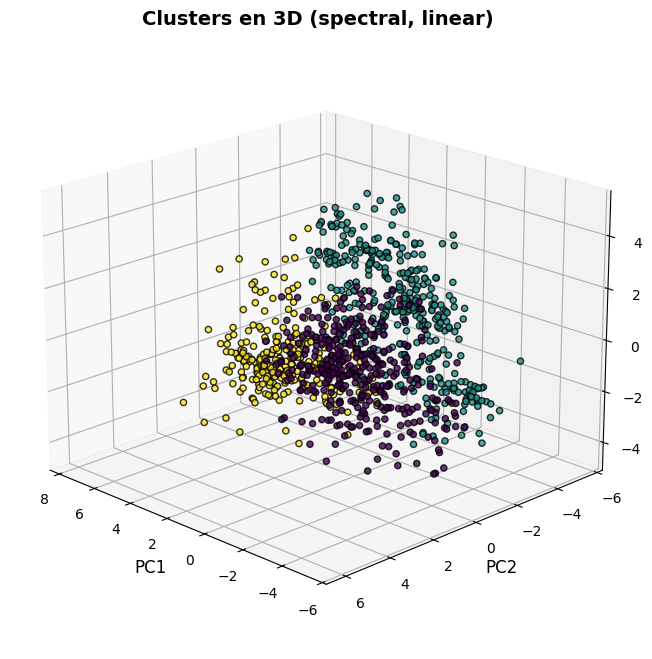

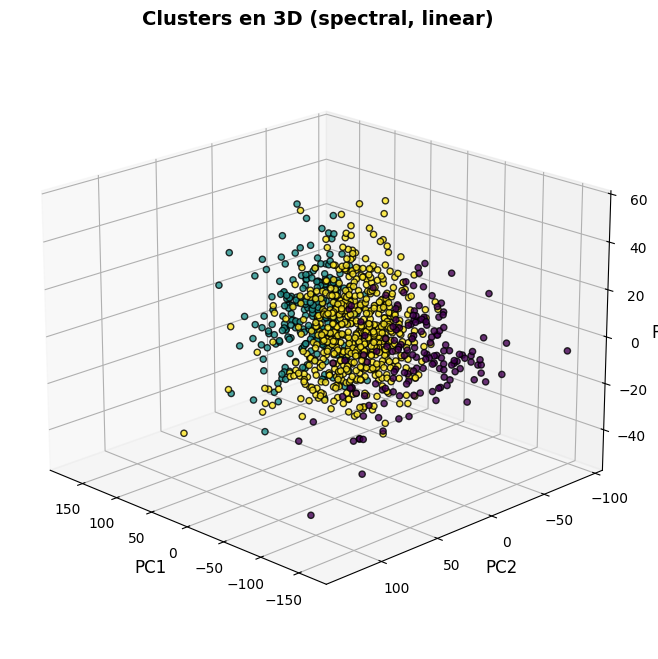

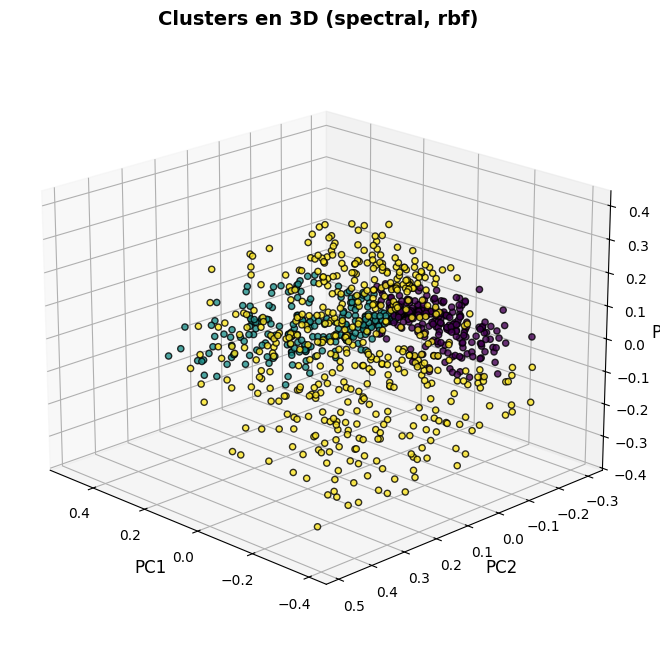

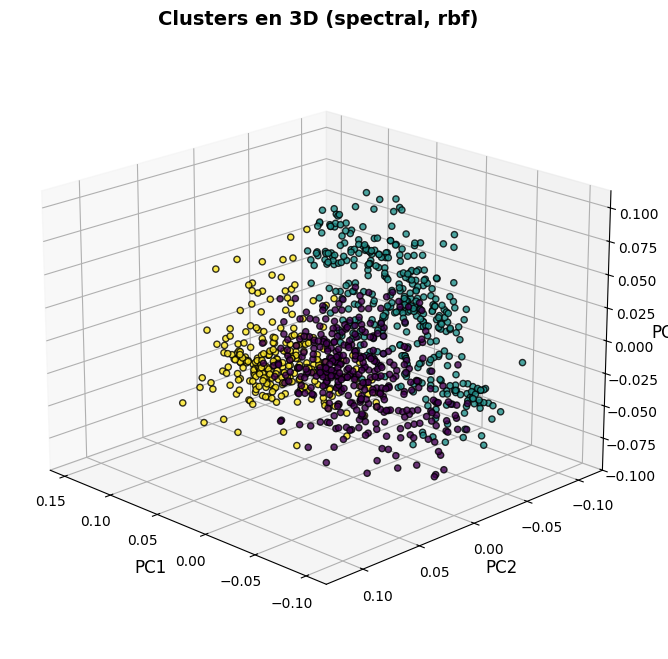

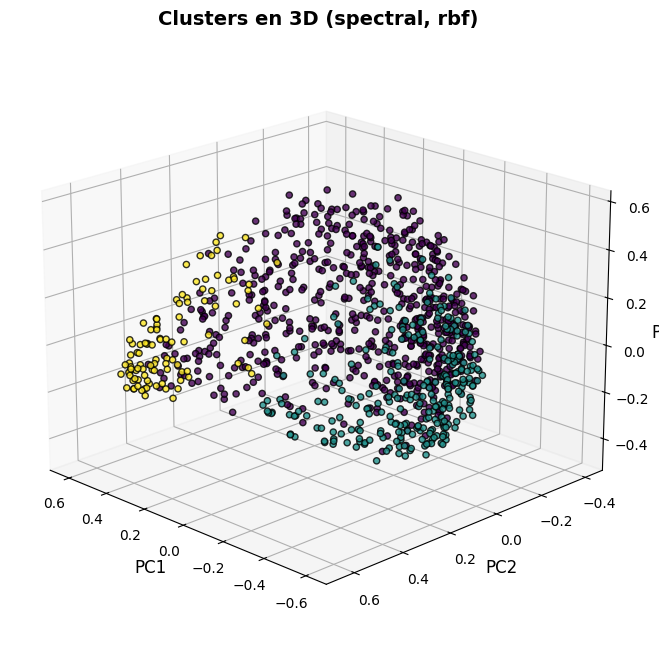

In [27]:
metodos = ["kmeans", "dbscan", "jerarquico",
           "mean-shift", "gmm", "spectral"]
kernels = ["linear", "rbf"]
representaciones = (X_image, X_text, X_all)

idx_representacion = {
    0 : "Histograma de intensidad",
    1 : "Histograma de color",
    2 : "ORB",
    3 : "Imagenes combinado",
    4 : "BOW",
    5 : "Doc2Vec",
    6 : "BERT",
    7 : "Texto combinado",
    8 : "Texto e Imagenes combinado"
}

resultados = dict()

for metodo in metodos:
    for kernel in kernels:
        for i, representacion in enumerate(representaciones):
            save = False
            if i in [3, 7, 8]:
                save = True
            print(
                f"Experimentando con algoritmo {metodo} y kernel {kernel} en representación de {idx_representacion[i]}.")
            cs = experimentacion(
                representacion, idx_representacion[i], metodo, 3, kernel, save=save)
            resultados[(metodo, kernel, idx_representacion[i])] = cs

Guardamos el resultado de la experimentación: Combinacion de algoritmos junto a su coeficiente de siluetas.

In [28]:
pickle.dump(resultados, open("resultados.p", "wb"))
sorted(resultados.items(), key=lambda x: x[1], reverse=True)

[(('mean-shift', 'linear', 'Histograma de intensidad'), 0.3355942916411839),
 (('mean-shift', 'linear', 'ORB'), 0.3294972705854823),
 (('spectral', 'rbf', 'ORB'), 0.22737831876969022),
 (('spectral', 'linear', 'Histograma de intensidad'), 0.22493918936234014),
 (('spectral', 'linear', 'ORB'), 0.21830211809704117),
 (('kmeans', 'linear', 'Histograma de intensidad'), 0.21334537836574327),
 (('kmeans', 'linear', 'ORB'), 0.2064775109721497),
 (('jerarquico', 'linear', 'Histograma de intensidad'), 0.19879360572727062),
 (('jerarquico', 'linear', 'ORB'), 0.1963016913395889),
 (('kmeans', 'rbf', 'ORB'), 0.19535568238964535),
 (('gmm', 'rbf', 'ORB'), 0.19290452206594488),
 (('gmm', 'linear', 'Histograma de intensidad'), 0.18797226961466248),
 (('gmm', 'linear', 'ORB'), 0.1825575218564796),
 (('jerarquico', 'rbf', 'ORB'), 0.17767686171078498),
 (('spectral', 'rbf', 'Histograma de intensidad'), 0.14274899074338254),
 (('gmm', 'rbf', 'Histograma de intensidad'), 0.1035768493647133),
 (('jerarquic

In [1]:
import pickle
resultados = pickle.load(open("resultados.p", "rb"))
sorted(resultados.items(), key=lambda x: x[1], reverse=True)

[(('mean-shift', 'linear', 'Histograma de intensidad'), 0.3355942916411839),
 (('mean-shift', 'linear', 'ORB'), 0.3294972705854823),
 (('spectral', 'rbf', 'ORB'), 0.22737831876969022),
 (('spectral', 'linear', 'Histograma de intensidad'), 0.22493918936234014),
 (('spectral', 'linear', 'ORB'), 0.21830211809704117),
 (('kmeans', 'linear', 'Histograma de intensidad'), 0.21334537836574327),
 (('kmeans', 'linear', 'ORB'), 0.2064775109721497),
 (('jerarquico', 'linear', 'Histograma de intensidad'), 0.19879360572727062),
 (('jerarquico', 'linear', 'ORB'), 0.1963016913395889),
 (('kmeans', 'rbf', 'ORB'), 0.19535568238964535),
 (('gmm', 'rbf', 'ORB'), 0.19290452206594488),
 (('gmm', 'linear', 'Histograma de intensidad'), 0.18797226961466248),
 (('gmm', 'linear', 'ORB'), 0.1825575218564796),
 (('jerarquico', 'rbf', 'ORB'), 0.17767686171078498),
 (('spectral', 'rbf', 'Histograma de intensidad'), 0.14274899074338254),
 (('gmm', 'rbf', 'Histograma de intensidad'), 0.1035768493647133),
 (('jerarquic